#Navigable Small World (NSW) - Constructing

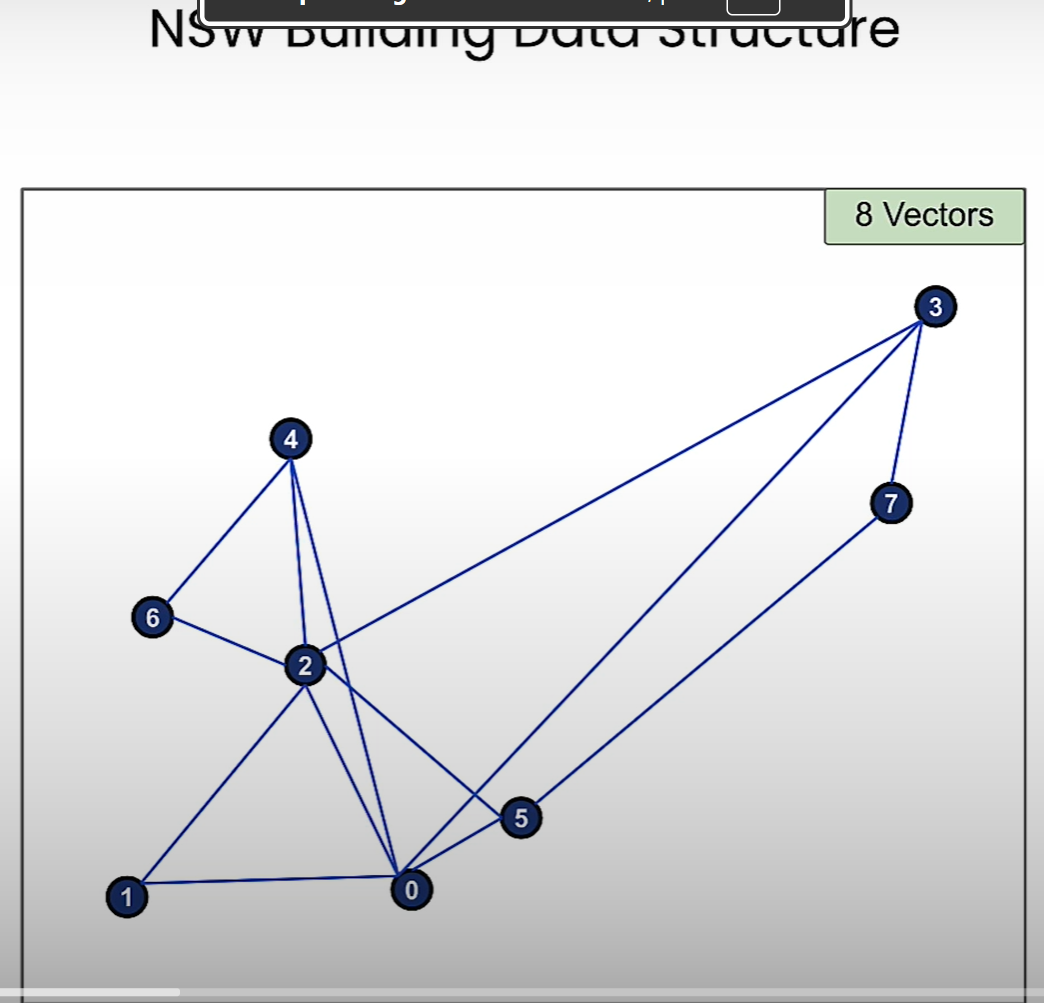

#NSW - Search 1: Nearest Neighbor
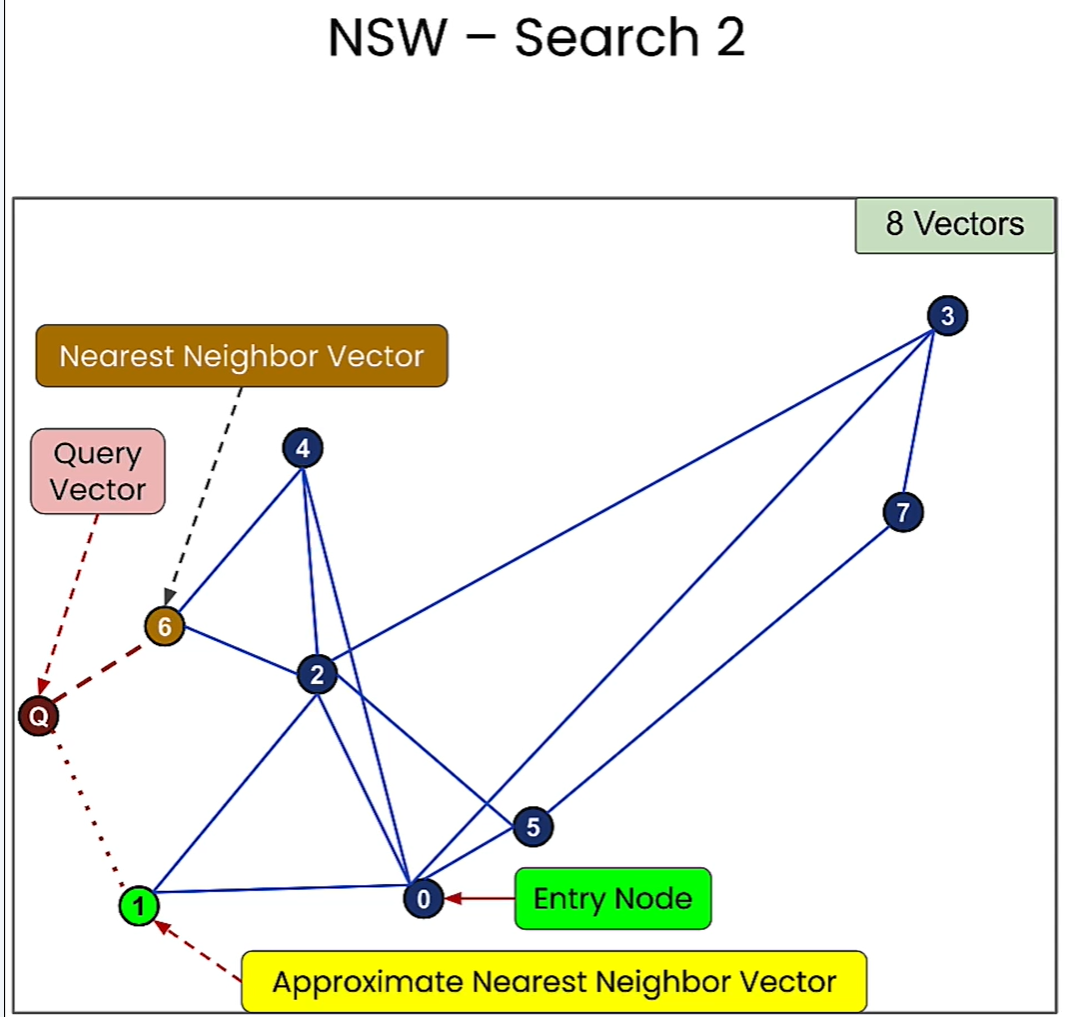



#Hirerachical Navigable Small World (HNSW) - Search

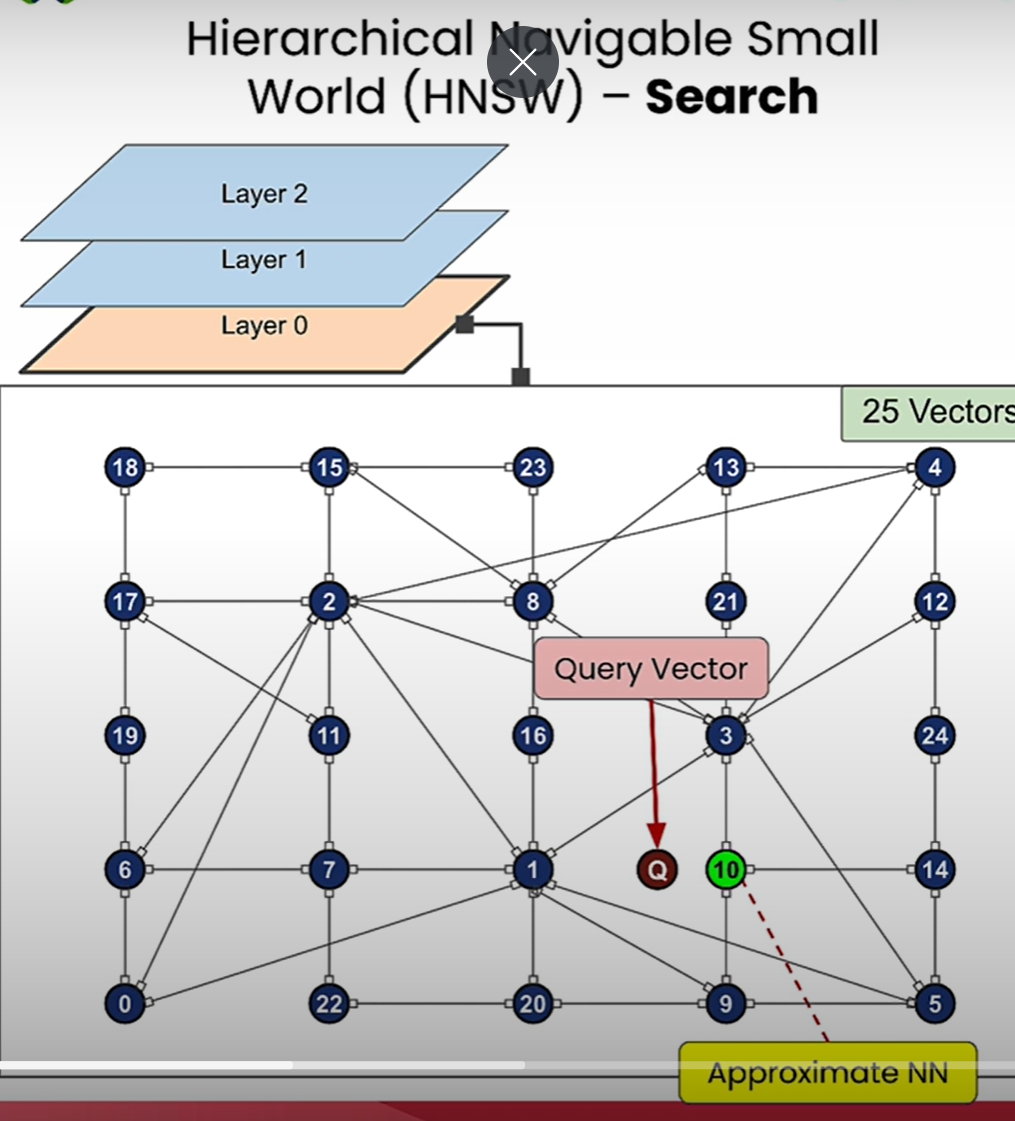

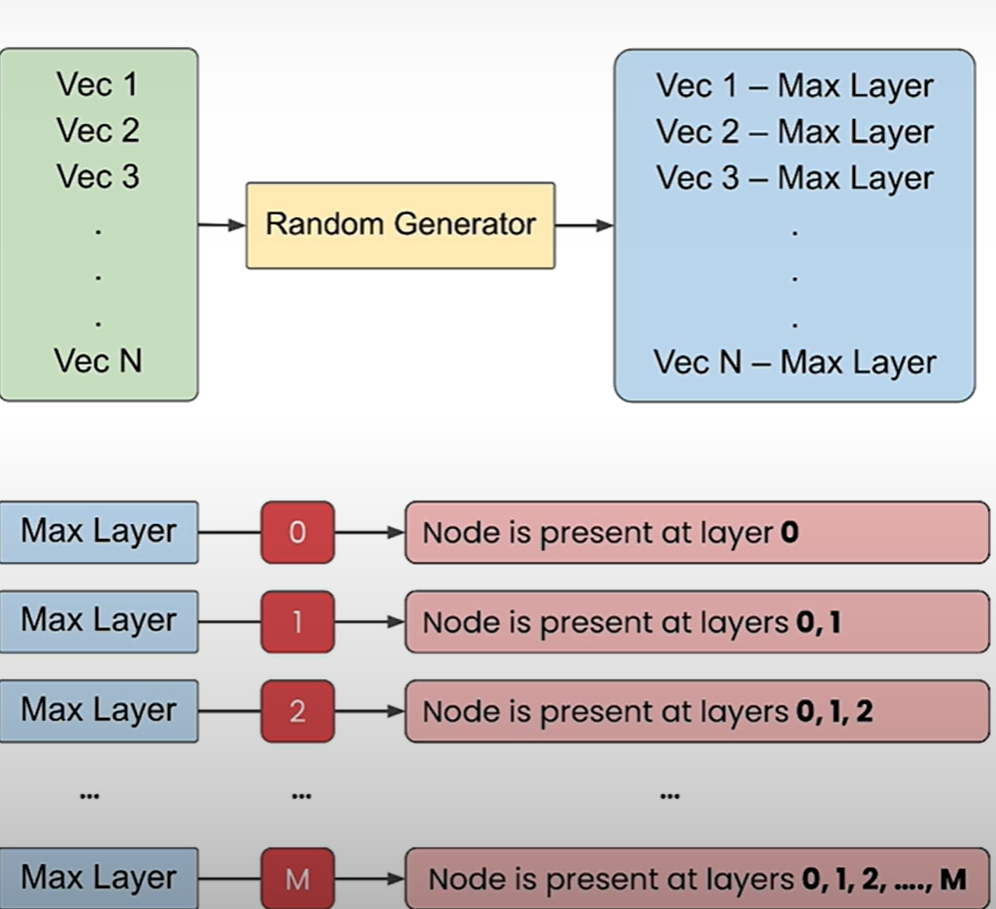

#HNSW Runtime
##Low likelihood in Higher Levels  
The likelihood of a vector being found on the higher up levels of our HNSW graph goes down exponentially

##Query time increase logarthimically

This means that as the number of datapoints increases the number of comparisions to perform vector search only goes up logarithimically

O(logn) runtime complexity

As a results we have o(log(N)) complexity for the HNSW algorithm




In [ ]:
!rm -rf ~/.local/share/weaviate

#Approximate Nearest Neighbors



In [ ]:
from random import random, randint
from math import floor, log
import networkx as nx
import numpy as np
import matplotlib as mtplt
from matplotlib import pyplot as plt
#from utils import *

In [ ]:
vec_num = 40 # number of vector (nodes)
dim = 2 ## Dimention. Set to be 2. All the graph plots are for dim 2. If changed, then plots should be commented.
m_nearest_neighbor = 2 # # M Nearest Neigbor used in construction of the Navigable Small World (NSW)
vec_pos = np.random.uniform(size=(vec_num,dim))
print(vec_pos)

[[0.17460694 0.88896781]
 [0.81972773 0.99700605]
 [0.93348435 0.41210269]
 [0.25469317 0.06334892]
 [0.8479979  0.40955637]
 [0.63768423 0.95446159]
 [0.05871566 0.97418933]
 [0.61658042 0.67626675]
 [0.74673666 0.54248517]
 [0.91886832 0.8542717 ]
 [0.96150019 0.00649013]
 [0.96244008 0.42353559]
 [0.36699375 0.75500096]
 [0.44031625 0.50017129]
 [0.86960674 0.67445807]
 [0.82540019 0.87877053]
 [0.79502755 0.01688181]
 [0.00513537 0.31472442]
 [0.5060576  0.07142801]
 [0.03321576 0.2608974 ]
 [0.45989348 0.64129525]
 [0.86477979 0.70964121]
 [0.3827941  0.3060816 ]
 [0.12998337 0.62743262]
 [0.81490468 0.34180767]
 [0.9583776  0.60987252]
 [0.8282988  0.41747468]
 [0.83594321 0.24015232]
 [0.45793551 0.46322371]
 [0.6604216  0.46129624]
 [0.13207954 0.26689895]
 [0.8287492  0.81689876]
 [0.38367351 0.96767141]
 [0.16744095 0.35065575]
 [0.44471563 0.20343308]
 [0.71620416 0.52167897]
 [0.96542868 0.99993122]
 [0.36049473 0.23018451]
 [0.41021456 0.25848382]
 [0.27197682 0.30980981]]

In [ ]:
#Query
query_vec = [0.5,0.5]
nodes = []
nodes.append(("Q",{"pos":query_vec}))
print(nodes)
print(query_vec)

[('Q', {'pos': [0.5, 0.5]})]
[0.5, 0.5]


In [ ]:
G_query = nx.Graph()
G_query.add_nodes_from(nodes)
print(G_query)

Graph with 1 nodes and 0 edges


In [ ]:
print("nodes = ", nodes, flush=True)

nodes =  [('Q', {'pos': [0.5, 0.5]})]


In [ ]:
pos_query=nx.get_node_attributes(G_query,'pos')
print(pos_query)

{'Q': [0.5, 0.5]}


HNSW has two main phases

1. Construction:	Build multiple graph layers where higher layers are sparse.

2. Search:	Start from the top layer and greedily move closer to the query

Each node:

Gets a random level

Exists in all layers from 0 up to its level

Is connected to M nearest neighbors per layer

Then during search:

You start from the topmost layer

Use greedy search

Move layer by layer downward

This makes search fast:
👉 O(log N) instead of O(N) brute force.

In [ ]:
import numpy as np
import networkx as nx
import random
from sklearn.metrics import pairwise_distances

# ----------------------------------------------------
# Distance function (Euclidean)
# ----------------------------------------------------
def dist(a, b):
    return np.linalg.norm(a - b)

# ----------------------------------------------------
# Greedy search inside a single HNSW layer
# ----------------------------------------------------
def greedy_search(graph, query_pos, entry):
    best = entry
    best_dist = dist(query_pos, np.array(graph.nodes[best]["pos"]))

    improved = True
    while improved:
        improved = False
        for nb in graph.neighbors(best):
            d = dist(query_pos, np.array(graph.nodes[nb]["pos"]))
            if d < best_dist:
                best = nb
                best_dist = d
                improved = True

    return best

# ----------------------------------------------------
# Full HNSW-style search through all layers
# ----------------------------------------------------
def hnsw_search(GraphArray, query_pos):
    """
    GraphArray: list of NetworkX graphs (layer 0, 1, ..., top)
    query_pos: numpy array (dim,)
    """
    top_layer = GraphArray[-1]

    entry = list(top_layer.nodes)[0]    # start from node 0 (simplified)

    # Traverse from top layer to bottom layer
    for layer in reversed(range(len(GraphArray))):
        entry = greedy_search(GraphArray[layer], query_pos, entry)

    return entry

# ----------------------------------------------------
# HNSW construction (multi-layer graph building)
# ----------------------------------------------------
def construct_HNSW(vec_pos, M=3):
    """
    vec_pos: numpy array of shape (N, dim)
             Each row is the position of one node.
    M: maximum number of neighbors per layer

    Returns:
        GraphArray: list of NetworkX graphs (one graph per layer)
    """

    # -------------------------------
    # Step 0: Number of nodes
    # -------------------------------
    N = len(vec_pos)

    # -------------------------------
    # Step 1: Assign random levels
    # -------------------------------
    levels = []
    for _ in range(N):
        lvl = 0
        while random.random() < 0.5:
            lvl += 1
        levels.append(lvl)

    # -------------------------------
    # Step 2: Create empty graphs
    # -------------------------------
    max_level = max(levels)

    GraphArray = []
    for _ in range(max_level + 1):
        GraphArray.append(nx.Graph())

    # -------------------------------
    # Step 3: Insert nodes into layers
    # -------------------------------
    for node in range(N):
        node_level = levels[node]

        # Insert this node into all layers from 0 to node_level
        for layer in range(node_level + 1):
            G = GraphArray[layer]

            # Add node with its position
            G.add_node(node, pos=tuple(vec_pos[node]))

            # If this is not the first node in this layer, connect neighbors
            if len(G.nodes) > 1:

                # Get already existing nodes in this layer
                existing_nodes = list(G.nodes)
                existing_nodes.remove(node)

                # Get their positions
                coords = np.array([G.nodes[n]["pos"] for n in existing_nodes])

                # Compute distances from this node to all existing nodes
                dists = pairwise_distances(
                    vec_pos[node].reshape(1, -1),
                    coords
                )[0]

                # Select M nearest neighbors
                nn_idx = np.argsort(dists)[:M]
                neighbors = [existing_nodes[i] for i in nn_idx]

                # Add edges
                for nb in neighbors:
                    G.add_edge(node, nb)

    return GraphArray

# ----------------------------------------------------
# MAIN PROGRAM (RUN THIS)
# ----------------------------------------------------
if __name__ == "__main__":

    # Fix randomness for reproducibility
    np.random.seed(1)
    random.seed(1)

    # -------------------------------
    # Step 1: Generate random node positions
    # -------------------------------
    vec_num = 20     # number of nodes
    dim = 2          # 2D positions

    vec_pos = np.random.uniform(size=(vec_num, dim))

    print("Node Positions:\n", vec_pos)

    # -------------------------------
    # Step 2: Construct HNSW Graph
    # -------------------------------
    GraphArray = construct_HNSW(vec_pos, M=3)

    print("\nNumber of layers =", len(GraphArray))
    for i, G in enumerate(GraphArray):
        print(f"Layer {i}: Nodes = {len(G.nodes)}, Edges = {len(G.edges)}")

    # -------------------------------
    # Step 3: Query point
    # -------------------------------
    query = np.array([0.5, 0.5])

    # -------------------------------
    # Step 4: Run HNSW search
    # -------------------------------
    nn = hnsw_search(GraphArray, query)

    print("\nQuery =", query)
    print("Nearest Neighbor ID =", nn)
    print("Nearest Neighbor Position =", vec_pos[nn])


Node Positions:
 [[4.17022005e-01 7.20324493e-01]
 [1.14374817e-04 3.02332573e-01]
 [1.46755891e-01 9.23385948e-02]
 [1.86260211e-01 3.45560727e-01]
 [3.96767474e-01 5.38816734e-01]
 [4.19194514e-01 6.85219500e-01]
 [2.04452250e-01 8.78117436e-01]
 [2.73875932e-02 6.70467510e-01]
 [4.17304802e-01 5.58689828e-01]
 [1.40386939e-01 1.98101489e-01]
 [8.00744569e-01 9.68261576e-01]
 [3.13424178e-01 6.92322616e-01]
 [8.76389152e-01 8.94606664e-01]
 [8.50442114e-02 3.90547832e-02]
 [1.69830420e-01 8.78142503e-01]
 [9.83468338e-02 4.21107625e-01]
 [9.57889530e-01 5.33165285e-01]
 [6.91877114e-01 3.15515631e-01]
 [6.86500928e-01 8.34625672e-01]
 [1.82882773e-02 7.50144315e-01]]

Number of layers = 14
Layer 0: Nodes = 20, Edges = 54
Layer 1: Nodes = 11, Edges = 27
Layer 2: Nodes = 6, Edges = 12
Layer 3: Nodes = 2, Edges = 1
Layer 4: Nodes = 1, Edges = 0
Layer 5: Nodes = 1, Edges = 0
Layer 6: Nodes = 1, Edges = 0
Layer 7: Nodes = 1, Edges = 0
Layer 8: Nodes = 1, Edges = 0
Layer 9: Nodes = 1, Edge

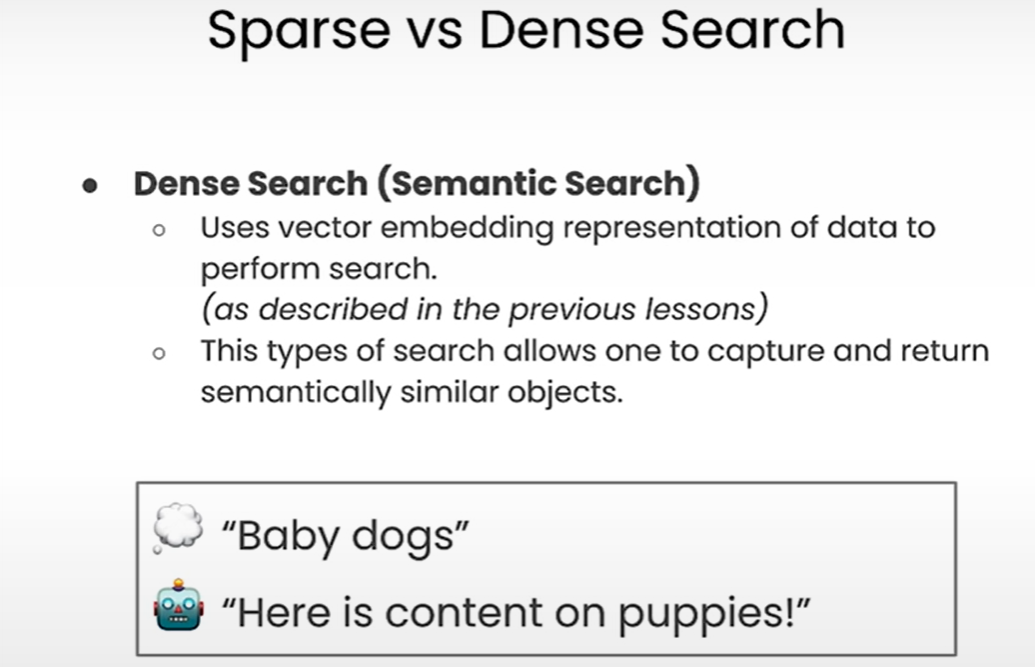

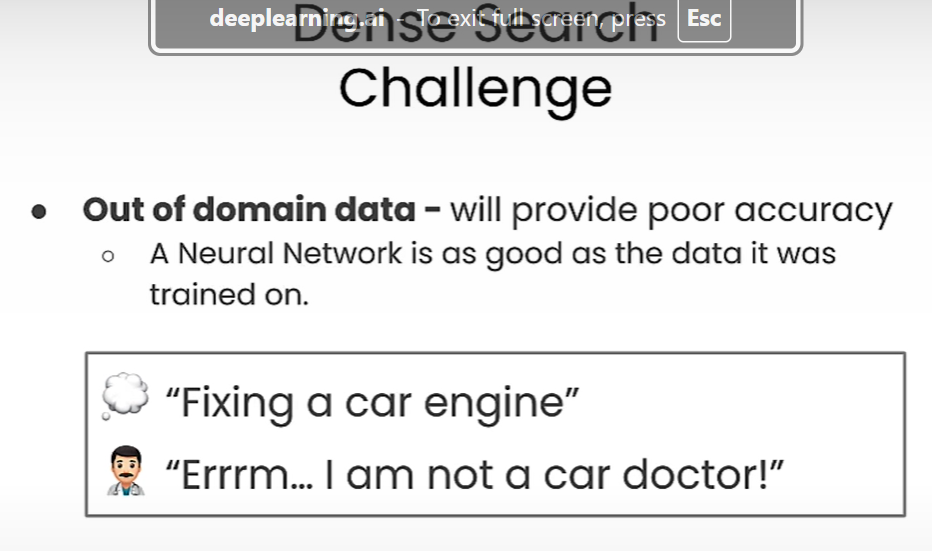

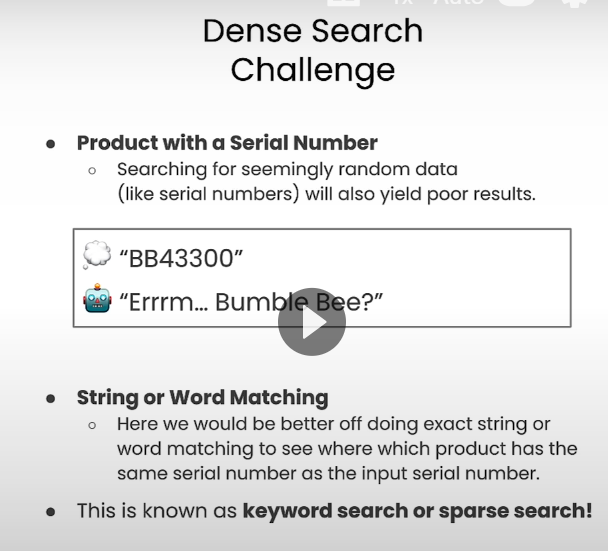

#Sparse search
it has bag of words
Raw text converts into bag of words

#The Bag of words

The easiest way to do keyword matching is using Bag of Words - to cound how many times a word occurs in the query and data vector and then return objects with the highest matching word frequencies.


#This is known as Sparse search
because the text is embedded into vectors by counting how many times every unique word in your vocabular occurs in the query and stored sentences

#Mostly Zeors (Sparse embedding)

Since the likelihood of any given sentence containing every word in you vocabulary is quite low the embeddings is mostly zeroes and thus is known as sparse embedding.




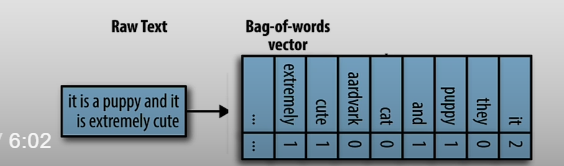